In [64]:
import random
import sys
from typing import Iterable

import numpy as np
import pandas as pd
import torch
from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

In [65]:
print(f"Python     : {sys.version.split()[0]}")
print(f"datasets   : {__import__('datasets').__version__}")
print(f"transformers: {__import__('transformers').__version__}")
print(f"torch      : {torch.__version__}")

Python     : 3.14.0
datasets   : 4.8.4
transformers: 5.4.0
torch      : 2.10.0+cpu


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

RANDOM_STATE = 19
set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Берём стандартную мультиязычную BERT-модель: она хорошо подходит для русскоязычных примеров.
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

print("Model loaded:", MODEL_NAME)
print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)
print("Model max length:", tokenizer.model_max_length)

Device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: bert-base-multilingual-cased
Tokenizer loaded: bert-base-multilingual-cased
Tokenizer class: BertTokenizer
Model class: BertForSequenceClassification
Number of labels: 2
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
Model max length: 512


### Данные и первичный анализ

In [3]:
full_dataset = load_dataset("ag_news")

# Разбиваем train на train+val
train_val_split = full_dataset['train'].train_test_split(
    test_size=0.25, 
    seed=RANDOM_STATE,
    stratify_by_column="label"
)

final_dataset = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'],
    'test': full_dataset['test']
})

print("Финальные размеры:")
print(f"Train:      {len(final_dataset['train']):>6}")
print(f"Validation: {len(final_dataset['validation']):>6}")
print(f"Test:       {len(final_dataset['test']):>6}")

# Sanity check
class_names = final_dataset['train'].features['label'].names
print(f"\nКлассы в train: {class_names}")

Финальные размеры:
Train:       90000
Validation:  30000
Test:         7600

Классы в train: ['World', 'Sports', 'Business', 'Sci/Tech']


In [4]:
train_df = final_dataset['train']
val_df = final_dataset['validation']
test_df = final_dataset['test']

Задача - классификация новостей по тематике (World, Sports, Business, Sci/Tech)

In [5]:
for i in range(5):
    example = train_df[i]
    text = example['text']
    label = example['label']
    
    print(f"\nПример {i+1:2d}: {class_names[label]:12s} | {label}")
    print(f"Текст:  {text[:150]}{'...' if len(text)>150 else ''}")
    print("-" * 70)


Пример  1: Sci/Tech     | 3
Текст:  Red Hat upgrades security Linux software maker Red Hat on Tuesday released an update to its enterprise product with security upgrades, support for IBM...
----------------------------------------------------------------------

Пример  2: Sports       | 1
Текст:  Fans have other favorites, but Busch has other ideas As Busch celebrated his 2004 Nextel Cup championship, most of the 80,000 fans turned their backs ...
----------------------------------------------------------------------

Пример  3: Sci/Tech     | 3
Текст:  Solaris 10 Supports High-Volume 64-Bit Computing Santa Clara, CA; November 22, 2004 -- Sun Microsystems and AMD are celebrating the one-year anniversa...
----------------------------------------------------------------------

Пример  4: Sci/Tech     | 3
Текст:  Supercomputers Aid Hurricane Forecasting Thousands of miles from the rain and wind of Hurricane Ivan, a model of the storm swirls in the memory and pr...
-----------------------

In [6]:
print("\nРаспределение классов в train:")
print(train_df.to_pandas()["label"].value_counts().sort_index())

print("\nРаспределение классов в validation:")
print(val_df.to_pandas()["label"].value_counts().sort_index())

print("Распределение классов в test:")
display(test_df.to_pandas()["label"].value_counts().sort_index())


Распределение классов в train:
label
0    22500
1    22500
2    22500
3    22500
Name: count, dtype: int64

Распределение классов в validation:
label
0    7500
1    7500
2    7500
3    7500
Name: count, dtype: int64
Распределение классов в test:


label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64

In [7]:
print("Пример из train:")
display(final_dataset["train"][:3])

print("\nПример из validation:")
display(final_dataset["validation"][:3])

Пример из train:


{'text': ['Red Hat upgrades security Linux software maker Red Hat on Tuesday released an update to its enterprise product with security upgrades, support for IBM Power5 servers, new driver support and bug fixes.',
  'Fans have other favorites, but Busch has other ideas As Busch celebrated his 2004 Nextel Cup championship, most of the 80,000 fans turned their backs and walked out of Homestead-Miami Speedway, leaving the 26-year-old first-time champion to himself.',
  'Solaris 10 Supports High-Volume 64-Bit Computing Santa Clara, CA; November 22, 2004 -- Sun Microsystems and AMD are celebrating the one-year anniversary of their strategic partnership.'],
 'label': [3, 1, 3]}


Пример из validation:


{'text': ['This weekend on TV, radio FRIDAY COLLEGE BASKETBALL/MEN 7:30 p.m. -- Memphis at Purdue, ESPN2 PRO BASKETBALL 7:30 p.m. -- Celtics vs. Toronto at the FleetCenter, FSN, WWZN (1510) 8 p.m. -- Detroit at San Antonio, ESPN 10:30 p.m. -- Indiana at Sacramento, ESPN BOXING 9:30 p.m. -- Friday Night Fights at Atlantic City: Rocky Juarez vs. Guty Espadas Jr. (featherweights), ESPN2 GOLF 1:30 p.m. ...',
  'Tool time for Microsoft In Denmark, Gates outlines effort to trim data managment costs, new Windows update service. Also: Angling for Novell users.',
  "Gov't panel: No cybersecurity mandates needed WASHINGTON - Now is not the time for the U.S. government to mandate cybersecurity standards to private industry, despite significant threats and a lack of understanding by many company executives, a panel of government officials said Tuesday."],
 'label': [1, 3, 3]}

### Токенизация

In [8]:
def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = final_dataset.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Parameter 'function'=<function tokenize_batch at 0x0000027F89B3FC10> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 90000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [9]:
for i in range(5):
    print(f"\n---Пример {i+1}---")
    example = tokenized_datasets["train"][:5]
    print("Ключи примера:", example.keys())
    print("labels:", example["label"])
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    print("Декодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))


---Пример 1---
Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: [3, 1, 3, 3, 3]
input_ids[:20]: [[101, 11641, 48024, 107003, 10107, 21849, 19291, 16042, 94038, 11641, 48024, 10135, 70245, 11539, 10151, 35896, 10114, 10474, 89245, 21535, 10169, 21849, 107003, 10107, 117, 13145, 10142, 21689, 12952, 11166, 38854, 10107, 117, 10751, 25926, 13145, 10111, 14460, 85884, 10107, 119, 102], [101, 68408, 10529, 10684, 55768, 10107, 117, 10473, 55947, 10393, 10684, 23802, 10882, 55947, 42710, 10226, 10264, 24721, 10570, 11544, 20755, 117, 10992, 10108, 10105, 10832, 117, 10259, 20950, 21031, 10455, 12014, 10107, 10111, 33734, 10336, 10950, 10108, 13898, 11157, 11488, 118, 17626, 62986, 117, 21005, 10105, 10314, 118, 10924, 118, 12898, 10422, 118, 10635, 17689, 10114, 14764, 119, 102], [101, 86608, 10150, 39007, 10107, 11956, 118, 15239, 11295, 118, 55568, 68716, 11154, 23086, 117, 24707, 132, 10819, 10306, 117, 10264, 118, 118, 13967, 78857, 95799, 101

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(3, 60)
token_type_ids: shape=(3, 60)
attention_mask: shape=(3, 60)
labels: shape=(3,)


### Инференс готовой модели

In [11]:
texts = final_dataset["train"][:5]['text']
texts

['Red Hat upgrades security Linux software maker Red Hat on Tuesday released an update to its enterprise product with security upgrades, support for IBM Power5 servers, new driver support and bug fixes.',
 'Fans have other favorites, but Busch has other ideas As Busch celebrated his 2004 Nextel Cup championship, most of the 80,000 fans turned their backs and walked out of Homestead-Miami Speedway, leaving the 26-year-old first-time champion to himself.',
 'Solaris 10 Supports High-Volume 64-Bit Computing Santa Clara, CA; November 22, 2004 -- Sun Microsystems and AMD are celebrating the one-year anniversary of their strategic partnership.',
 'Supercomputers Aid Hurricane Forecasting Thousands of miles from the rain and wind of Hurricane Ivan, a model of the storm swirls in the memory and processors of a supercomputer that can predict its likely course and strength.',
 'Siemens awarded 2G/3G network extension in Malaysia Malaysia #39;s Maxis Communications Bhd. (Maxis) has selected Sieme

In [12]:
def predict_one_text(text: str) -> Dict[str, Any]:
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())

    result = {
        "text": text,
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_score": pred_score,
        "logits": logits.cpu().numpy().round(4).tolist()[0],
        "probabilities": probs.cpu().numpy().round(4).tolist()[0],
    }
    return result

single_example = texts[0]
manual_result = predict_one_text(single_example)

pd.DataFrame(
    {
        "field": list(manual_result.keys()),
        "value": [manual_result[key] for key in manual_result.keys()],
    }
)

,field,value
0,text,Red Hat upgrades security Linux software maker...
1,pred_id,0
2,pred_label,LABEL_0
3,pred_score,0.574191
4,logits,"[-0.017999999225139618, -0.31700000166893005]"
5,probabilities,"[0.5741999745368958, 0.42579999566078186]"


In [13]:
def probability_table(text: str) -> pd.DataFrame:
    result = predict_one_text(text)
    labels = [model.config.id2label[i] for i in range(model.config.num_labels)]
    df = pd.DataFrame(
        {
            "label": labels,
            "probability": result["probabilities"],
        }
    ).sort_values("probability", ascending=False, ignore_index=True)
    df.insert(0, "text", text)
    return df

probability_table(texts[2])

,text,label,probability
0,Solaris 10 Supports High-Volume 64-Bit Computi...,LABEL_0,0.5856
1,Solaris 10 Supports High-Volume 64-Bit Computi...,LABEL_1,0.4144


In [14]:
def predict_many_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_row in zip(texts, pred_ids, probs):
        pred_label = model.config.id2label[int(pred_id)]
        pred_score = float(prob_row[int(pred_id)])
        row = {
            "text": text,
            "manual_label": pred_label,
            "manual_score": pred_score,
        }
        for i in range(model.config.num_labels):
            row[model.config.id2label[i]] = float(prob_row[i])
        rows.append(row)

    return pd.DataFrame(rows)

manual_df = predict_many_texts(texts)
manual_df

,text,manual_label,manual_score,LABEL_0,LABEL_1
0,Red Hat upgrades security Linux software maker...,LABEL_0,0.574191,0.574191,0.425809
1,"Fans have other favorites, but Busch has other...",LABEL_0,0.505846,0.505846,0.494154
2,Solaris 10 Supports High-Volume 64-Bit Computi...,LABEL_0,0.585614,0.585614,0.414386
3,Supercomputers Aid Hurricane Forecasting Thous...,LABEL_0,0.573131,0.573131,0.426869
4,Siemens awarded 2G/3G network extension in Mal...,LABEL_0,0.623861,0.623861,0.376139


Результаты показывают, что предобученная BERT-base не подходит для классификации AG News, поскольку дает только ~55% accuracy. Для достижения более высоких значений необходим fine-tuning.

### Fine-tuning для классификации текста

In [36]:
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = final_dataset.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Polina\.cache\huggingface\hub\models--cointegrated--rubert-tiny2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 90000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [37]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]
label2id = {name: idx for idx, name in enumerate(label_names)}
id2label = {idx: name for name, idx in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'World': 0, 'Sports': 1, 'Business': 2, 'Sci/Tech': 3}
id2label: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [38]:
model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

print("Model class:", model_ft.__class__.__name__)
print("Number of labels:", model_ft.config.num_labels)
print("id2label:", model_ft.config.id2label)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

Model class: BertForSequenceClassification
Number of labels: 4
id2label: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [39]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [43]:
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [44]:
try:
    trainer = Trainer(
        model=model_ft,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model_ft,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.789362,0.314246,0.910933,0.910728,0.910728
2,0.021514,0.291050,0.923867,0.923859,0.923859
3,0.086482,0.304064,0.927167,0.927122,0.927122


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=33750, training_loss=0.27200570068841246, metrics={'train_runtime': 7477.4927, 'train_samples_per_second': 36.108, 'train_steps_per_second': 4.514, 'total_flos': 344058203064576.0, 'train_loss': 0.27200570068841246, 'epoch': 3.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.723187,11.248805,0.00002,0.000178,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.553143,6.317139,0.00002,0.000356,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.529672,8.841306,0.00002,0.000533,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.711316,7.039253,0.00002,0.000711,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.605950,8.714869,0.00002,0.000889,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.551744,11.615735,0.00002,0.001067,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.745105,16.224373,0.00002,0.001244,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.624836,6.384051,0.00002,0.001422,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.737447,5.820344,0.00002,0.001600,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.591791,9.838698,0.00002,0.001778,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


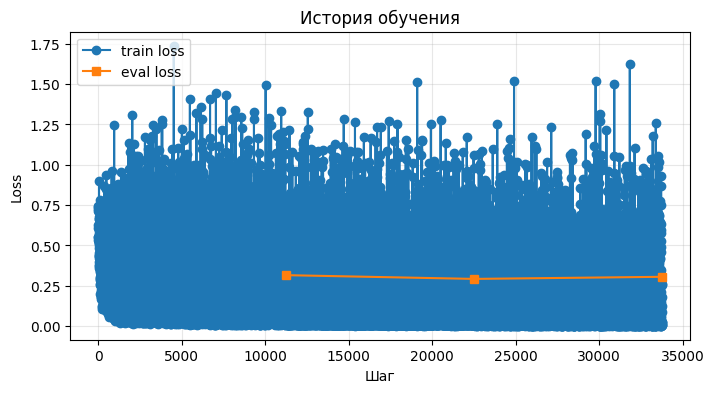

In [47]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [48]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.3041
eval_accuracy: 0.9272
eval_f1_macro: 0.9271
eval_f1_weighted: 0.9271
eval_runtime: 90.7176
eval_samples_per_second: 330.6970
eval_steps_per_second: 20.6690
epoch: 3.0000

Test metrics:
eval_loss: 0.3077
eval_accuracy: 0.9292
eval_f1_macro: 0.9291
eval_f1_weighted: 0.9291
eval_runtime: 24.7189
eval_samples_per_second: 307.4570
eval_steps_per_second: 19.2160
epoch: 3.0000


In [50]:
texts_t = final_dataset["test"][:100]['text']
texts_t

["Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.",
 'The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\\privately funded suborbital space flight, has officially announced the first\\launch date for its manned rocket.',
 'Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.',
 "Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in pl

In [52]:
# 1. Создание sample_predictions.csv
test_predictions = trainer.predict(tokenized_datasets["test"])

# Получаем предсказания и истинные метки
preds = np.argmax(test_predictions.predictions, axis=1)
true_labels = test_predictions.label_ids

C:\Users\Polina\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [58]:
# Берем 100 примеров для sample
sample_indices = np.random.choice(len(final_dataset['test']), 100, replace=False)

sample_df = pd.DataFrame({
    'text': [final_dataset['test'][i]['text'][:100] + "..." for i in sample_indices],
    'true_label': [id2label[true_labels[i]] for i in sample_indices],
    'pred_label': [id2label[preds[i]] for i in sample_indices],
    'confidence': [np.max(test_predictions.predictions[i]) for i in sample_indices]
})


# Сохранение
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("sample_predictions.csv сохране!")
print(sample_df.head())


sample_predictions.csv сохране!
                                                text true_label pred_label  \
0  US admits more Afghan jail deaths The US army ...      World      World   
1  Wall St.'s Nest Egg - the Housing Sector  NEW ...   Business   Business   
2  Judge: Geico can sue Google, Overture over ads...   Business   Business   
3  Greek sprinters quit Games ATHENS (Reuters) - ...     Sports     Sports   
4  Six Shot Dead in New Northeast India Violence ...      World      World   

   confidence  
0    6.660331  
1    5.539496  
2    2.948690  
3    7.095040  
4    6.700220  


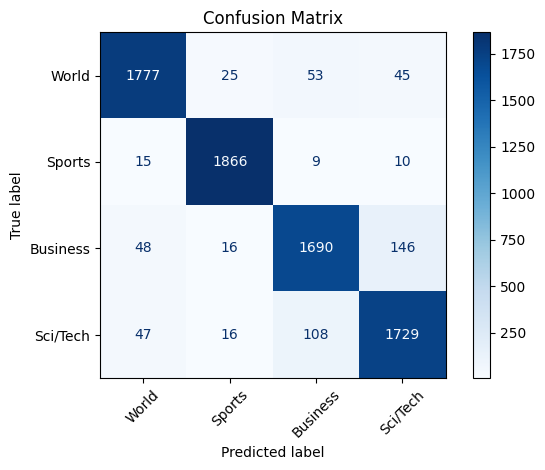

confusion_matrix.png сохранен


In [62]:
# 2. Confusion Matrix
# Полная confusion matrix на test
cm = confusion_matrix(true_labels, preds, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                             display_labels=list(id2label.values()))

disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("artifacts/confusion_matrix.png")
plt.show()
print("confusion_matrix.png сохранен")
